In [2]:
from collections        import defaultdict
from pandas             import DataFrame, read_csv
from matplotlib         import pyplot
from multiprocessing    import Pool
from numpy              import array, sum, max, mean, linalg, dot
from os                 import listdir, path
from random             import choice
from seaborn            import kdeplot
from typing             import Optional

from gffutils import load_gff, attributes_dict

# Long read correction benchmark

In [2]:
threads = 8

## 1. RAM/Time analysis

/tmp/ipykernel_10966/1731691229.py:34: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes.set_xlim(xmin=0,xmax=data["Time"].max()*1.1)
/tmp/ipykernel_10966/1731691229.py:35: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes.set_ylim(ymin=0,ymax=data["RAM"].max()*1.1)


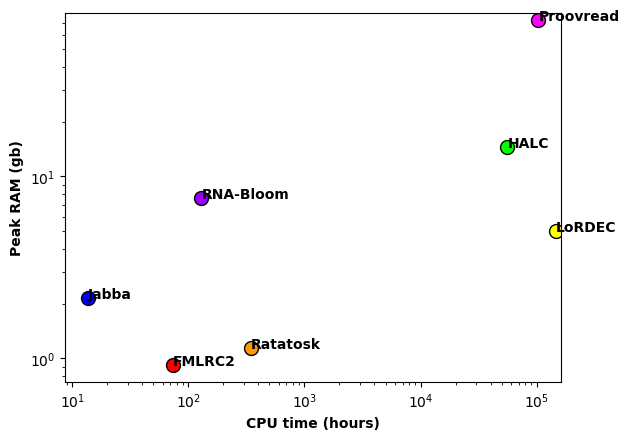

In [3]:
def random_color() -> str:

    return "#"+"".join([choice("0123456789ABCDEF") for _ in range(6)])

def load_benchmark(path: str) -> DataFrame:

    df         = read_csv(path, sep="\t")
    df["Time"] = round(df["Time"] / (60*2), 2)
    df["RAM"]  = round(df["RAM"]  / (1024**2), 2)

    return df

def plot_benchmark(axes,
                   data: DataFrame,
                   colors: Optional[dict[str, str]] = None,
                   xscale: Optional[str] = "linear",
                   yscale: Optional[str] = "linear"):

    if colors is None:
        colors = {tool: random_color() for tool in data["Tool"]}

    for i, row in data.iterrows():
        axes.text(row["Time"],row["RAM"],row["Tool"], fontweight="bold")
        axes.scatter([row["Time"]],[row["RAM"]],
                    color = colors[row["Tool"]],
                    label = row["Tool"],
                    edgecolor = "black",
                    s=100)
    
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlabel("CPU time (hours)", fontweight="bold")
    axes.set_ylabel("Peak RAM (gb)",    fontweight="bold")
    axes.set_xlim(xmin=0,xmax=data["Time"].max()*1.1)
    axes.set_ylim(ymin=0,ymax=data["RAM"].max()*1.1)

fig, axes = pyplot.subplots()
data      = load_benchmark("correction_time.tsv")
colors    = {"FMLRC2":      "#ff0000",
             "HALC":        "#00ff00",
             "Jabba":       "#0000ff",
             "LoRDEC":      "#ffff00",
             "Proovread":   "#ff00ff",
             "Ratatosk":    "#ff9900",
             "RNA-Bloom":   "#9900ff"}

plot_benchmark(axes, data, xscale="log", yscale="log", colors=colors)

## 2. Read lengths

In [4]:
lengths_df = read_csv("correction_read_lengths.tsv", sep="\t")

display(lengths_df)

,File,# Sequences,# Bases,Min len,Mean len,Max len,Std
0,fmlrc2.fasta,1000000,1447434970,138,1447,10643,930
1,fmlrc2lordec.fasta,1000000,1449031032,138,1449,10643,930
2,halc.fasta,1000000,1464965219,141,1464,10655,932
3,halc_s.fasta,1154199,1275200520,100,1104,5937,850
4,halc_t.fasta,999867,1348884260,14,1349,8322,885
5,jabba_corrected.fasta,826971,532780281,28,644,6669,728
6,jabba.fasta,1236594,911742130,28,737,9060,719
7,lordec.fasta,1000000,1459675670,144,1459,10643,934
8,lordec_s.fasta,1146361,1246825769,100,1087,5865,814
9,lordec_t.fasta,997479,1263040669,21,1266,5868,882


## 2. Isoform quantification analysis

### 2.1. Loading quantification results

We can observe, that the number of total counts sometimes differs from the number of reads.<br>
Unmapped reads decrease the number of total counts, multi-mapped reads increase it.

In [5]:
abundance_dfs = {file.split(".")[0]: read_csv(path.join("data_nanosim_quantification",file), sep="\t")
                 for file in listdir("data_nanosim_quantification")}
files         = sorted(abundance_dfs.keys())

a, b, c, d = "Reads", "Counts", "# Reads", "Difference"
print(f"| {a:<20} | {b:>10} | {c:>10} | {d:>10} |")
print("---------------------------------------------------------------")

for i, file in enumerate(files):
    total_counts = round(abundance_dfs[file]["count"].sum())
    n_sequences  = lengths_df["# Sequences"].iloc[i]
    print(f"| {file:<20} | {total_counts:>10} | {n_sequences:>10} | {n_sequences-total_counts:>10} |")

| Reads                |     Counts |    # Reads | Difference |
---------------------------------------------------------------
| fmlrc2               |     997064 |    1000000 |       2936 |
| fmlrc2lordec         |     998467 |    1000000 |       1533 |
| halc                 |    1049901 |    1000000 |     -49901 |
| halc_s               |    1166643 |    1154199 |     -12444 |
| halc_t               |    1039255 |     999867 |     -39388 |
| jabba                |    1187735 |     826971 |    -360764 |
| jabba_corrected      |     786593 |    1236594 |     450001 |
| lordec               |     997182 |    1000000 |       2818 |
| lordec_s             |    1142502 |    1146361 |       3859 |
| lordec_t             |     994764 |     997479 |       2715 |
| perfect              |     999993 |    1000000 |          7 |
| proovread            |     991486 |     999573 |       8087 |
| ratatosk             |     991624 |    1000000 |       8376 |
| ratatosk_split       |    2219870 |   

### 2.2 Creation of a gene to isoform map

Keys:   Gene IDs<br>
Values: Lists of corresponding RNA IDs

defaultdict(<class 'list'>, {'Gm26206': ['XR_004936710.1'], 'Xkr4': ['XM_006495550.5', 'NM_001011874.1', 'XM_011238395.4', 'XM_036152287.1'], 'Gm53491': ['XR_004935518.1', 'XR_004935517.1'], 'Rp1': ['XM_030252325.2', 'NM_001370921.1', 'NM_001195662.2', 'NM_011283.3'], 'Sox17': ['NM_001289467.1', 'NM_001289464.1', 'NM_001289466.1', 'NM_001289465.1', 'NM_011441.5', 'XM_030252410.2', 'XM_036162991.1', 'XM_030252405.1', 'XM_036162992.1'], 'Gm22307': ['XR_004936894.1'], 'Gm37323': ['XR_003947656.1', 'XR_001778812.2', 'XR_001778806.2', 'XR_003947660.2'], 'Gm39586': ['XR_003947708.1'], 'Gm46082': ['XR_001778820.2'], 'Gm29874': ['XR_001778816.2', 'XR_373196.3', 'XR_001778815.2', 'XR_001778819.2'], 'Mrpl15': ['NM_025300.4', 'NM_001177658.1', 'XM_006495524.4'], 'Lypla1': ['NM_008866.3', 'NM_001355712.1'], 'LOC118567656': ['XR_004935520.1'], 'Tcea1': ['NM_011541.4', 'NM_001159750.1', 'NM_001159751.1'], 'Rgs20': ['XM_036152522.1', 'XM_036152516.1', 'XM_011238400.2', 'XM_006495554.3', 'XM_036152539

,# Genes,# Isoforms,# AS genes,Avg. isoforms per gene
0,2356,7854,1179,3.334


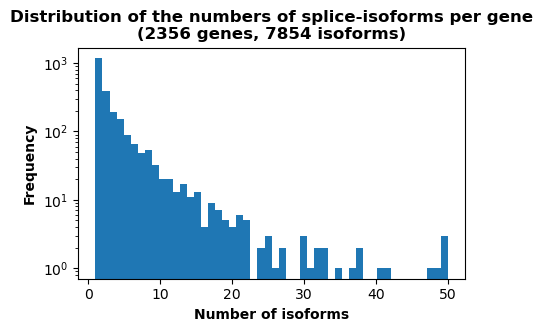

In [6]:
def get_gene2rna_map(gff: DataFrame)->dict[str, list[str]]:
    """
    Args:
        gff (DataFrame): Genome annotation as pandas.DataFrame
    Returns:
        dict[str, list[str]]:   keys:   Gene IDs
                                values: Lists of corresponding RNA IDs
    """
    gene2rna_map = defaultdict(list)                                                      # Creating an empty hashmap
    RNAs         = gff.loc[gff["type"].str.contains("RNA", na=False)]                     # Filter for rows containing RNAs
    
    for _, rna in RNAs.iterrows():
        rna_attrs = attributes_dict(rna)
        if "gene" in rna_attrs:
            gene2rna_map[rna_attrs["gene"]].append((rna_attrs["ID"].split("-")[1])) 
        
    return gene2rna_map

def get_gene2rna_map_stats(gene2rna_map: dict[str, list[str]]) -> DataFrame:
    
    n_isoforms = [len(gene2rna_map[gene]) for gene in gene2rna_map.keys()]
    
    return DataFrame({"# Genes":                [len(n_isoforms)],
                      "# Isoforms":             [sum(n_isoforms)],
                      "# AS genes":             [len([n for n in n_isoforms if n>1])],
                      "Avg. isoforms per gene": [round(sum(n_isoforms)/len(n_isoforms),3)]})
    
def gene2rna_map_plot(gene2rna_map: dict[str, list[str]]):
    
    n_isoforms = [len(gene2rna_map[gene]) for gene in gene2rna_map.keys()]
    
    # Formatting
    fig, axes = pyplot.subplots(figsize=(5,3))
    axes.set_title("Distribution of the numbers of splice-isoforms per gene\n"+
                   f"({len(n_isoforms)} genes, {sum(n_isoforms)} isoforms)",
                   fontweight="bold")
    axes.set_yscale("log")
    axes.set_xlabel("Number of isoforms", fontweight="bold")
    axes.set_ylabel("Frequency", fontweight="bold")

    # Plotting
    axes.hist(n_isoforms, bins=max(n_isoforms))

annotation      = load_gff("./annotation.gff")
annotation_chr1 = annotation.loc[(annotation["seqname"]=="NC_000067.7")]
gene2rna_map    = get_gene2rna_map(annotation_chr1)

print(gene2rna_map)
display(get_gene2rna_map_stats(gene2rna_map))
gene2rna_map_plot(gene2rna_map)

### 2.3 Filtering for genes with alternative splicing

,# Genes,# Isoforms,# AS genes,Avg. isoforms per gene
0,1179,6677,1179,5.663


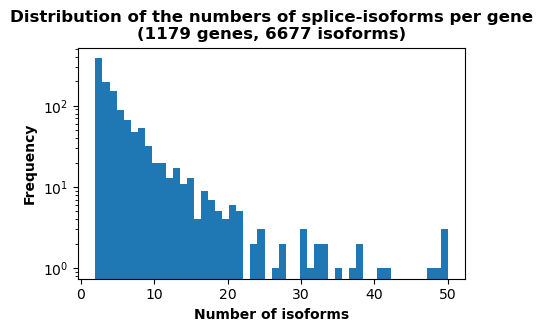

In [7]:
gene2rna_map = {gene: gene2rna_map[gene]
                for gene in gene2rna_map.keys() if len(gene2rna_map[gene])>1}
display(get_gene2rna_map_stats(gene2rna_map))
gene2rna_map_plot(gene2rna_map)

### 2.4 Creating gene to splice-isoform counts maps

Keys:   Gene IDs<br>
Values: Lists of transcript counts

In [8]:
def get_gene2counts_map(gene2rna_map:   dict[str, list[float]],
                        abundance_data: DataFrame)->dict[str, list]:

    rna2counts_map  = dict({})
    
    for i, row in abundance_data.iterrows():
        rna2counts_map[str(row["ID"])]=float(row["count"])
        
    genes2counts_map = dict({})
    
    for gene in gene2rna_map.keys():

        genes2counts_map[gene] = [rna2counts_map[rna] if rna in rna2counts_map.keys() else 0 
                                  for rna in gene2rna_map[gene]]

    return genes2counts_map

def get_gene2counts_map_wrapper(args: tuple[dict[str, list],DataFrame])->dict[str, list]:
    
    return get_gene2counts_map(args[0],args[1])

with Pool(threads) as pool:
    args = zip([gene2rna_map for _ in files],[abundance_dfs[file] for file in files], )
    gene2counts_maps = pool.map(get_gene2counts_map_wrapper, args)
    
gene2counts_maps = {file: gene2counts_maps[i] for i, file in enumerate(files)}

### 2.5 Filtering for expressed genes

,# Genes,# Isoforms,# AS genes,Avg. isoforms per gene
0,916,5810,916,6.343


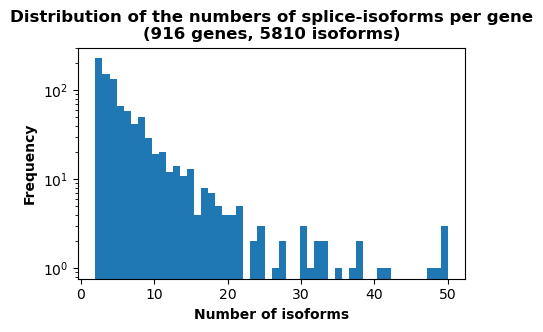

In [9]:
min_count = 3
exp_genes = [gene for gene in gene2counts_maps["raw"].keys() if sum(gene2counts_maps["raw"][gene]) >= min_count]

gene2counts_maps = {file: {gene: gene2counts_maps[file][gene]
                           for gene in exp_genes}
                    for file in files}
gene2rna_map = {gene: gene2rna_map[gene] for gene in exp_genes}

display(get_gene2rna_map_stats(gene2rna_map))
gene2rna_map_plot(gene2rna_map)

### 2.6 Major isoform counts and isoform consistency

In [10]:
def get_gene2major_index_map() -> dict[str, int]:
    
    return {gene: gene2counts_maps["raw"][gene].index(max(gene2counts_maps["raw"][gene]))
            for gene in gene2rna_map.keys()}
    
def get_gene2major_count_maps() -> dict[str, float]:
    
    return {file: {gene: gene2counts_maps[file][gene][gene2major_index_map[gene]]
                               for gene in gene2rna_map.keys()}
                        for file in files}
    
def get_genes2major_frac_maps():
    
    return {file: {gene: array(gene2counts_maps[file][gene][gene2major_index_map[gene]]) / sum(gene2counts_maps[file][gene]) if sum(gene2counts_maps[file][gene]) > 0 else 0
                               for gene in gene2rna_map.keys()}
                        for file in files}
    
def cosine_similarity(vec1: list, vec2: list) -> float:

    if (linalg.norm(vec1) * linalg.norm(vec2)):
        return dot(vec1, vec2) / (linalg.norm(vec1) * linalg.norm(vec2))
    elif (linalg.norm(vec1) + linalg.norm(vec2)):
        return 0
    else:
        return 1
    
def exp_similarities(gene2counts_map: dict[str, list[float]]) -> dict[str,float]:
 
    return {gene: cosine_similarity(gene2counts_map[gene], gene2counts_maps["raw"][gene])
            for gene in exp_genes}
        
gene2major_index_map  = get_gene2major_index_map()
gene2major_count_maps = get_gene2major_count_maps()
genes2major_frac_maps = get_genes2major_frac_maps()

In [11]:
print("| Reads           | Total major isoform counts | Mean major isoform fraction | Mean isoform consistency |")
print("|-----------------|----------------------------|-----------------------------|--------------------------|")

mic_raw = sum(list(gene2major_count_maps["raw"].values()))
mif_raw = mean(list(genes2major_frac_maps["raw"].values()))

for i, file in enumerate(files):
    
    mic_file = round(sum(list(gene2major_count_maps[file].values())),3)
    mif_file = round(mean(list(genes2major_frac_maps[file].values())),3)
    ic_file  = mean(list(exp_similarities(gene2counts_maps[file]).values()))

    print(f"| {file:<15} | {mic_file:>12.3f} ({mic_file-mic_raw:>11.3f}) | {mif_file:>18.3f} ({mif_file-mif_raw:>6.3f}) | {ic_file:>24.3f} |")

| Reads           | Total major isoform counts | Mean major isoform fraction | Mean isoform consistency |
|-----------------|----------------------------|-----------------------------|--------------------------|
| fmlrc2          |   449475.561 ( -63816.855) |              0.553 (-0.093) |                    0.863 |
| fmlrc2lordec    |   492464.879 ( -20827.537) |              0.587 (-0.059) |                    0.878 |
| halc            |   437939.634 ( -75352.782) |              0.501 (-0.145) |                    0.852 |
| halc_s          |   500845.063 ( -12447.353) |              0.472 (-0.174) |                    0.754 |
| halc_t          |   442903.208 ( -70389.208) |              0.501 (-0.145) |                    0.836 |
| jabba           |   565155.372 (  51862.956) |              0.590 (-0.056) |                    0.858 |
| jabba_corrected |   292838.808 (-220453.608) |              0.416 (-0.230) |                    0.618 |
| lordec          |   498185.707 ( -15106.709)

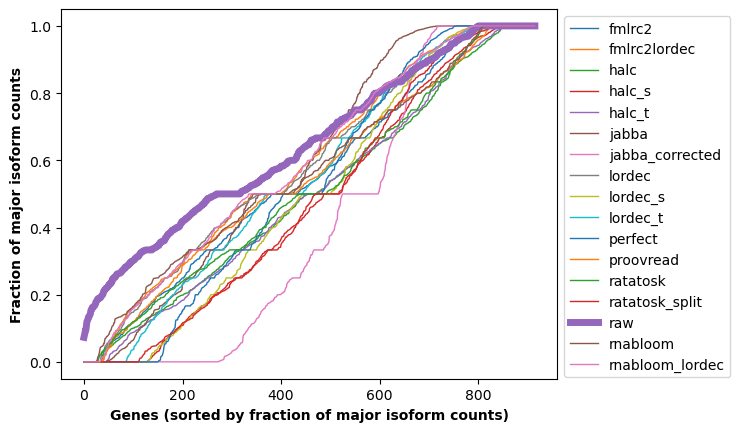

In [12]:
def fraction_of_major_isoform_plot():
    
    fig, axes = pyplot.subplots()
    
    # Plotting
    for file in files:
        lw = 5 if file=="raw" else 1
        y = sorted(genes2major_frac_maps[file].values())
        x = range(len(y))
        axes.plot(x, y, label=file, linewidth=lw)
        
    # General formatting
    axes.set_xlabel("Genes (sorted by fraction of major isoform counts)", fontweight="bold")
    axes.set_ylabel("Fraction of major isoform counts", fontweight="bold")
    axes.legend(bbox_to_anchor=(1,1,0,0))

fraction_of_major_isoform_plot()

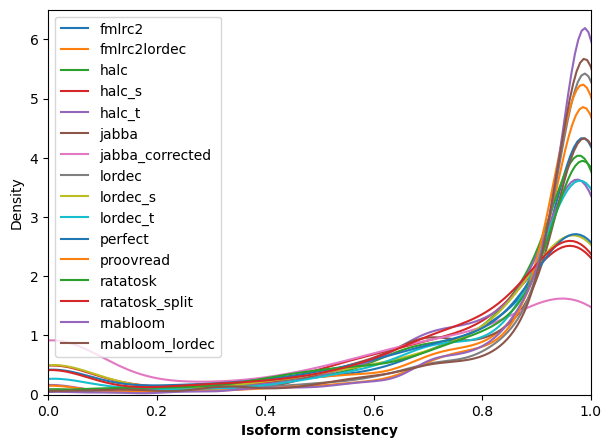

In [22]:
def similarity_distribution_plot(axes):
    
    for file in files:
        
        if not file=="raw":

            similarities = list(exp_similarities(gene2counts_maps[file]).values())
            kdeplot(similarities, ax=axes, label=file)

fig, axes = pyplot.subplots(figsize=(7,5))

similarity_distribution_plot(axes)
axes.set_xlim(xmin=0, xmax=1)
axes.set_xlabel("Isoform consistency", fontweight="bold")
axes.legend()

## 3 Cramino error rates

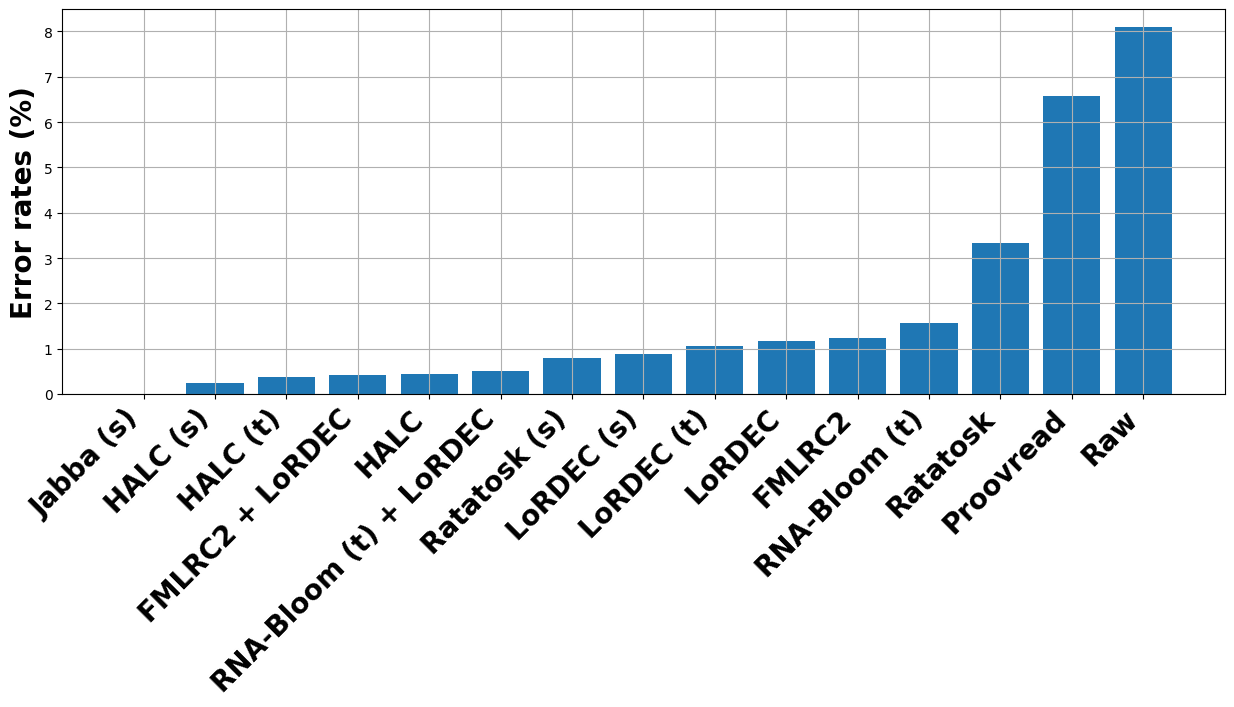

In [ ]:
cramino_error_rates = {"Raw":                    8.09,
                       "FMLRC2":                 1.23,
                       "FMLRC2 + LoRDEC":        0.41,
                       "HALC":                   0.45,
                       "LoRDEC":                 1.18,
                       "Proovread":              6.58,
                       "Ratatosk":               3.34,
                       "HALC (t)":               0.38,
                       "LoRDEC (t)":             1.05,
                       "RNA-Bloom (t)":          1.57,
                       "RNA-Bloom (t) + LoRDEC": 0.51,
                       "HALC (s)":               0.24,
                       "Jabba (s)":              0.00,
                       "LoRDEC (s)":             0.89,
                       "Ratatosk (s)":           0.79}

X = sorted(list(cramino_error_rates.keys()), key=lambda x: cramino_error_rates[x])
Y = [cramino_error_rates[x] for x in X]

fig, axes = pyplot.subplots(figsize=(15,5))

axes.bar(X, Y)
axes.set_ylabel("Error rates (%)", fontweight="bold", fontsize=20)
axes.set_xticks(X)
axes.set_xticklabels(X, fontweight="bold", rotation=45, ha="right", fontsize=20)
axes.grid()